### Load Dataset & Initial Inspection

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
df = pd.read_csv('2015.csv')

display(df.head())
display(df.info())

,Country,Region,Happiness Rank,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
0,Switzerland,Western Europe,1,7.587,0.03411,1.39651,1.34951,0.94143,0.66557,0.41978,0.29678,2.51738
1,Iceland,Western Europe,2,7.561,0.04884,1.30232,1.40223,0.94784,0.62877,0.14145,0.43630,2.70201
2,Denmark,Western Europe,3,7.527,0.03328,1.32548,1.36058,0.87464,0.64938,0.48357,0.34139,2.49204
3,Norway,Western Europe,4,7.522,0.03880,1.45900,1.33095,0.88521,0.66973,0.36503,0.34699,2.46531
4,Canada,North America,5,7.427,0.03553,1.32629,1.32261,0.90563,0.63297,0.32957,0.45811,2.45176


<class 'pandas.DataFrame'>
RangeIndex: 158 entries, 0 to 157
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Country                        158 non-null    str    
 1   Region                         158 non-null    str    
 2   Happiness Rank                 158 non-null    int64  
 3   Happiness Score                158 non-null    float64
 4   Standard Error                 158 non-null    float64
 5   Economy (GDP per Capita)       158 non-null    float64
 6   Family                         158 non-null    float64
 7   Health (Life Expectancy)       158 non-null    float64
 8   Freedom                        158 non-null    float64
 9   Trust (Government Corruption)  158 non-null    float64
 10  Generosity                     158 non-null    float64
 11  Dystopia Residual              158 non-null    float64
dtypes: float64(9), int64(1), str(2)
memory usage: 14.9 KB


None

## 1. Data Cleaning & Preparation

### Check Missing Data

In [2]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
Country                          0
Region                           0
Happiness Rank                   0
Happiness Score                  0
Standard Error                   0
Economy (GDP per Capita)         0
Family                           0
Health (Life Expectancy)         0
Freedom                          0
Trust (Government Corruption)    0
Generosity                       0
Dystopia Residual                0
dtype: int64


### Column Standardization

In [3]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(r'[^a-z0-9]+', '_', regex=True)
    .str.strip('_')
)

print(df.columns.tolist())

['country', 'region', 'happiness_rank', 'happiness_score', 'standard_error', 'economy_gdp_per_capita', 'family', 'health_life_expectancy', 'freedom', 'trust_government_corruption', 'generosity', 'dystopia_residual']


### Remove Duplicates

In [4]:
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows found: {duplicate_count}")

duplicate_countries = df['country'].duplicated().sum()
print(f"Number of duplicate country entries found: {duplicate_countries}")

df = df.drop_duplicates()
print(f"Dataset shape after removing duplicates: {df.shape}")

Number of duplicate rows found: 0
Number of duplicate country entries found: 0
Dataset shape after removing duplicates: (158, 12)


## 2. Summary Statistics & Correlation Analysis

### Summary Statistics

In [5]:
numerical_cols = [
    'happiness_score',
    'economy_gdp_per_capita',
    'family',
    'health_life_expectancy',
    'freedom',
    'trust_government_corruption',
    'generosity'
]

display(df[numerical_cols].describe())

print("\nMode values:")
print(df[numerical_cols].mode().iloc[0])

,happiness_score,economy_gdp_per_capita,family,health_life_expectancy,freedom,trust_government_corruption,generosity
count,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000
mean,5.375734,0.846137,0.991046,0.630259,0.428615,0.143422,0.237296
std,1.145010,0.403121,0.272369,0.247078,0.150693,0.120034,0.126685
min,2.839000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.526000,0.545808,0.856823,0.439185,0.328330,0.061675,0.150553
50%,5.232500,0.910245,1.029510,0.696705,0.435515,0.107220,0.216130
75%,6.243750,1.158448,1.214405,0.811013,0.549092,0.180255,0.309883
max,7.587000,1.690420,1.402230,1.025250,0.669730,0.551910,0.795880



Mode values:
happiness_score                5.19200
economy_gdp_per_capita         0.00000
family                         0.00000
health_life_expectancy         0.92356
freedom                        0.00000
trust_government_corruption    0.32524
generosity                     0.00000
Name: 0, dtype: float64


### Correlation Matrix

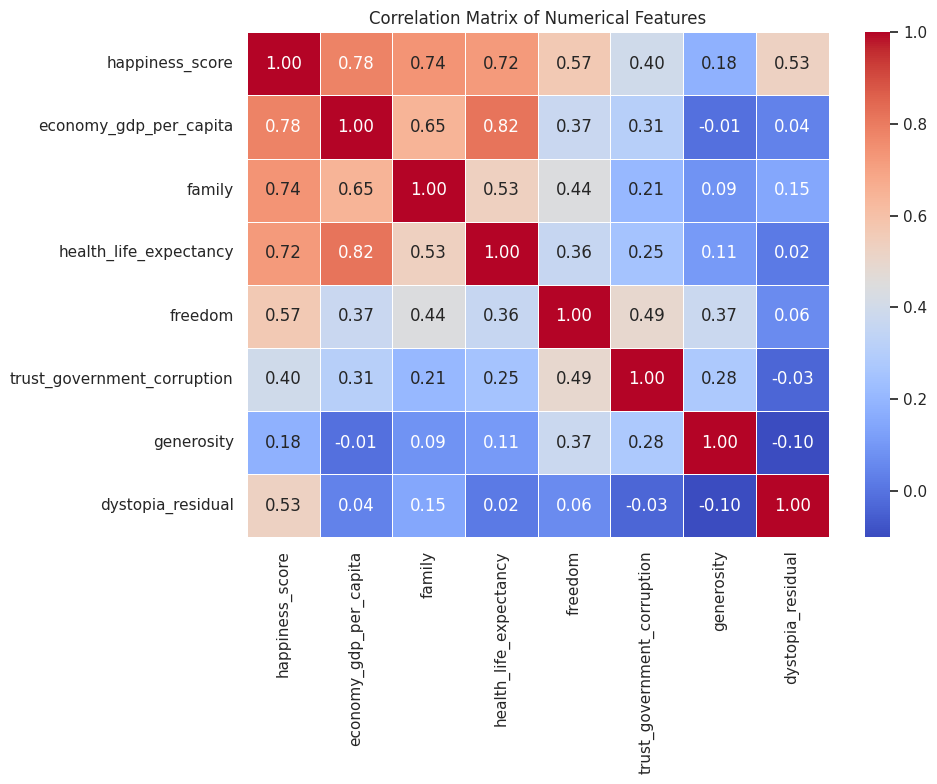

In [6]:
corr_cols = numerical_cols + ['dystopia_residual']
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features')
plt.tight_layout()
plt.show()

## 3. Top & Bottom Performing Countries

In [7]:
top5 = df.nlargest(5, 'happiness_score')[['country', 'happiness_score']]
bottom5 = df.nsmallest(5, 'happiness_score')[['country', 'happiness_score']]

display(top5)
display(bottom5)

,country,happiness_score
0,Switzerland,7.587
1,Iceland,7.561
2,Denmark,7.527
3,Norway,7.522
4,Canada,7.427


,country,happiness_score
157,Togo,2.839
156,Burundi,2.905
155,Syria,3.006
154,Benin,3.340
153,Rwanda,3.465


/tmp/ipykernel_535/3668640929.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top5, y='country', x='happiness_score', palette='Greens_r', ax=axes[0])
/tmp/ipykernel_535/3668640929.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=bottom5, y='country', x='happiness_score', palette='Reds_r', ax=axes[1])


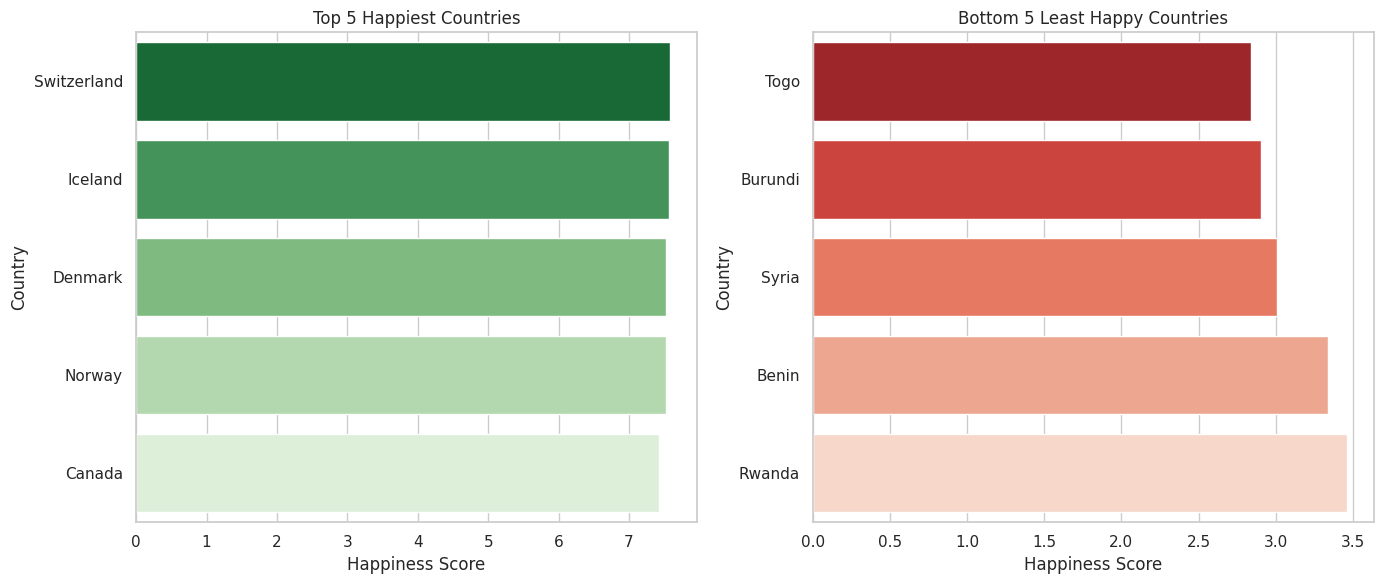

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(data=top5, y='country', x='happiness_score', palette='Greens_r', ax=axes[0])
axes[0].set_title('Top 5 Happiest Countries')
axes[0].set_xlabel('Happiness Score')
axes[0].set_ylabel('Country')

sns.barplot(data=bottom5, y='country', x='happiness_score', palette='Reds_r', ax=axes[1])
axes[1].set_title('Bottom 5 Least Happy Countries')
axes[1].set_xlabel('Happiness Score')
axes[1].set_ylabel('Country')

plt.tight_layout()
plt.show()

## 4. Regional Happiness Distribution

In [9]:
regional_summary = df.groupby('region').agg(
    avg_happiness_score=('happiness_score', 'mean'),
    avg_economy_gdp_per_capita=('economy_gdp_per_capita', 'mean')
).sort_values('avg_happiness_score', ascending=False)

display(regional_summary)

,avg_happiness_score,avg_economy_gdp_per_capita
region,,
Australia and New Zealand,7.285000,1.291880
North America,7.273000,1.360400
Western Europe,6.689619,1.298596
Latin America and Caribbean,6.144682,0.876815
Eastern Asia,5.626167,1.151780
Middle East and Northern Africa,5.406900,1.066974
Central and Eastern Europe,5.332931,0.942438
Southeastern Asia,5.317444,0.789054
Southern Asia,4.580857,0.560486


/tmp/ipykernel_535/3700589628.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


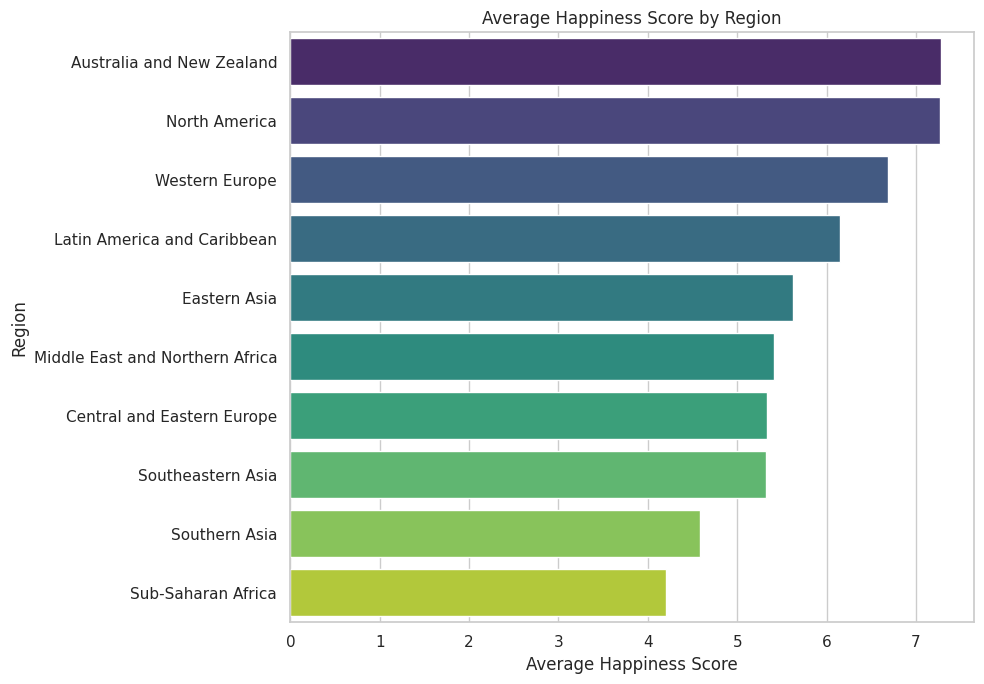

In [10]:
plt.figure(figsize=(10, 7))
sns.barplot(
    data=regional_summary.reset_index(),
    y='region',
    x='avg_happiness_score',
    palette='viridis'
)
plt.title('Average Happiness Score by Region')
plt.xlabel('Average Happiness Score')
plt.ylabel('Region')
plt.tight_layout()
plt.show()

## 5. Factor Impact Analysis (Scatter Plot & Regression)

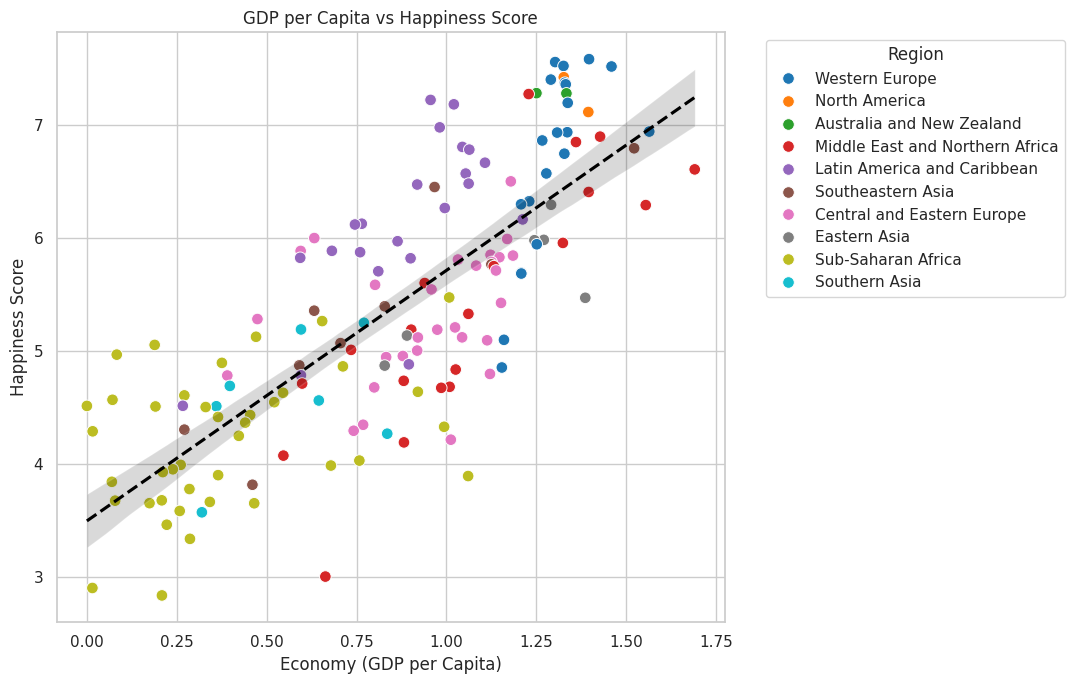

In [11]:
plt.figure(figsize=(11, 7))
sns.scatterplot(
    data=df,
    x='economy_gdp_per_capita',
    y='happiness_score',
    hue='region',
    palette='tab10',
    s=70
)
sns.regplot(
    data=df,
    x='economy_gdp_per_capita',
    y='happiness_score',
    scatter=False,
    color='black',
    line_kws={'linestyle': '--', 'label': 'Trendline'}
)
plt.title('GDP per Capita vs Happiness Score')
plt.xlabel('Economy (GDP per Capita)')
plt.ylabel('Happiness Score')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Region')
plt.tight_layout()
plt.show()

## 6. Corruption vs. Freedom Segmentation

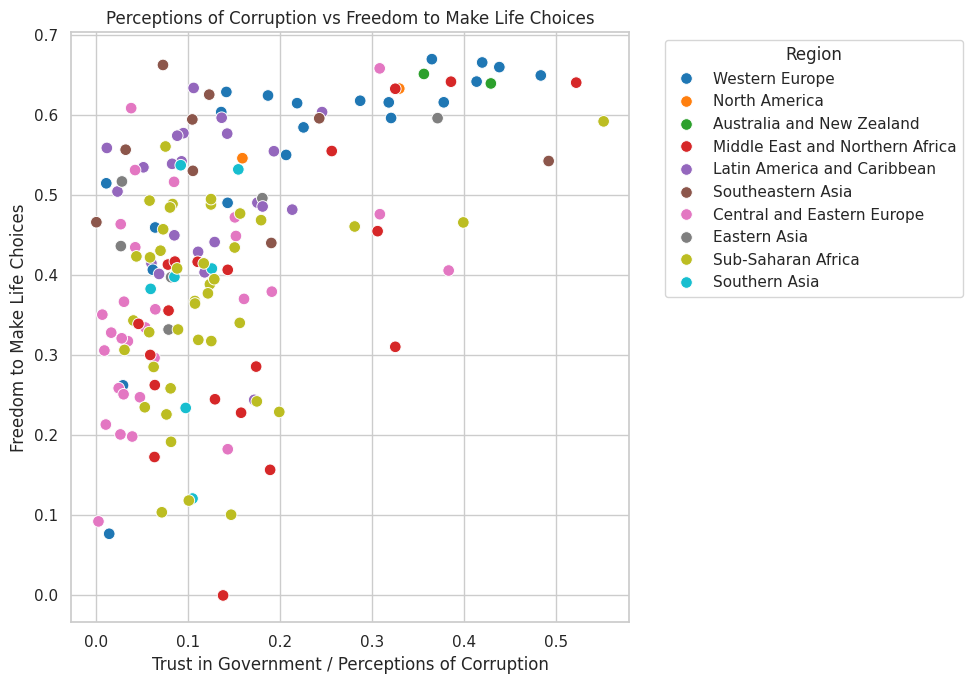

In [12]:
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=df,
    x='trust_government_corruption',
    y='freedom',
    hue='region',
    palette='tab10',
    s=70
)
plt.title('Perceptions of Corruption vs Freedom to Make Life Choices')
plt.xlabel('Trust in Government / Perceptions of Corruption')
plt.ylabel('Freedom to Make Life Choices')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Region')
plt.tight_layout()
plt.show()